In [1]:
import pandas as pd
import numpy as np 
import nltk 
from gensim.models import word2vec
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy 


In [2]:
review_data = pd.read_csv('../data/processed_data/drugsComTrain_text_preprocessing.csv')

In [3]:
review_data.head()

,Unnamed: 0,Unnamed: 0.1,drug_id,drugName,condition,review,rating,date,usefulCount,lowered_review,...,stemmed_review,lemmatized_review,review_len,stemmed_review_len,lem_review_len,word_count,sentiment_vader,sentiment_vader_label,sentiment_textblob,sentiment_textblob_label
0,0,0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,2012-05-20,27,"""it has no side effect, i take it in combinati...",...,no side effect take combin bystol mg fish oil,no side effect take combin bystol mg fish oil,46,45,45,9,-0.2960,Negative,0.000000,neutral
1,1,1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,2010-04-27,192,"""my son is halfway through his fourth week of ...",...,son halfway fourth week intuniv becam concern ...,son halfway fourth week intuniv becam concern ...,372,369,367,65,0.6929,Positive,0.114583,positive
2,2,2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,2009-12-14,17,"""i used to take another oral contraceptive, wh...",...,use take anoth oral contracept pill cycl happi...,use take anoth oral contracept pill cycl happi...,403,401,401,70,0.2732,Positive,0.105000,positive
3,3,3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,2015-11-03,10,"""this is my first time using any form of birth...",...,first time use form birth control glad went pa...,first time use form birth control glad went pa...,226,223,225,39,0.1027,Positive,0.300000,positive
4,4,4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,2016-11-27,37,"""suboxone has completely turned my life around...",...,suboxon complet turn life around feel healthie...,suboxon complet turn life around feel healthie...,380,378,379,58,0.8934,Positive,0.147037,positive


In [4]:
column_names=['sentiment_vader_label','sentiment_textblob_label','stopwords_remove_review','drug_id','drugName','condition','rating']
review_data_new = review_data[column_names]



In [5]:
review_data_new.head()

,sentiment_vader_label,sentiment_textblob_label,stopwords_remove_review,drug_id,drugName,condition,rating
0,Negative,neutral,no side effect take combin bystol mg fish oil,206461,Valsartan,Left Ventricular Dysfunction,9.0
1,Positive,positive,son halfway fourth week intuniv becam concern ...,95260,Guanfacine,ADHD,8.0
2,Positive,positive,use take anoth oral contracept pill cycl happi...,92703,Lybrel,Birth Control,5.0
3,Positive,positive,first time use form birth control glad went pa...,138000,Ortho Evra,Birth Control,8.0
4,Positive,positive,suboxon complet turn life around feel healthie...,35696,Buprenorphine / naloxone,Opiate Dependence,9.0


Word Embeddings:

Tf_idf 

In [6]:
tf_idf = TfidfVectorizer()

In [7]:
tfidf_matrix = tf_idf.fit_transform(review_data_new['stopwords_remove_review'])

In [8]:
tfidf_matrix.get_shape()

(160392, 55625)

In [9]:
feature_names = tf_idf.get_feature_names_out()

CLASSIFICATION USING MACHINE LEARNING AND DEEP LEARNING

Support vector Machine

Linear SVC with TextBlob label

In [10]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt 
import seaborn as sns

In [11]:
x=tfidf_matrix
y1=review_data_new['sentiment_textblob_label']


In [12]:
# spliting of train and test data for each of the sentiment analyzer : 
# tf_idf & y1(textblob label): 
X1_train, X1_test, y1_train, y1_test = train_test_split(x, y1, test_size=0.2, shuffle=True)



In [13]:
svc = LinearSVC()

In [14]:
Text_blob_model=svc.fit(X1_train,y1_train)

c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [15]:
y1_pred = Text_blob_model.predict(X1_test)

In [16]:
conf_textblob= confusion_matrix(y1_test, y1_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_textblob, display_labels = [False, True])

In [17]:
accuracy_textblob =  metrics.accuracy_score(y1_test,y1_pred)
print(accuracy_textblob)

0.9666760185791328


In [18]:
#confusion matrix metrics
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

    negative       0.95      0.94      0.95      8529
     neutral       0.97      0.95      0.96      3401
    positive       0.97      0.98      0.98     20149

    accuracy                           0.97     32079
   macro avg       0.96      0.96      0.96     32079
weighted avg       0.97      0.97      0.97     32079



In [19]:
labels = ['positive','negative','neutral']

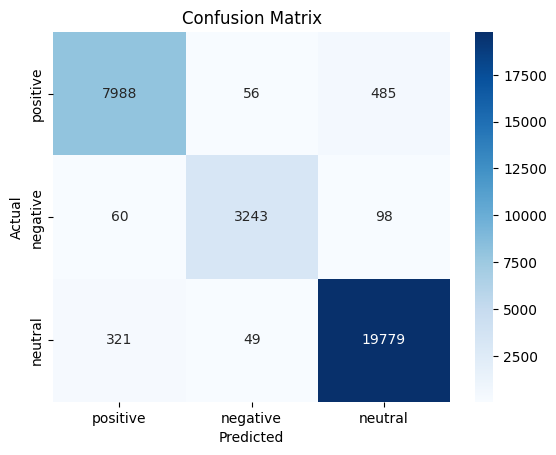

In [20]:
sns.heatmap(conf_textblob, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Linear SVC With Vader Label

In [21]:
y2=review_data_new['sentiment_vader_label']
x=tfidf_matrix

In [22]:
# tf_idf & y2(vader label):
X2_train, X2_test, y2_train, y2_test = train_test_split(x, y2, test_size=0.2, shuffle=True)

In [23]:
vader_model = svc.fit(X2_train,y2_train)

c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [24]:
y2_pred=vader_model.predict(X2_test)

In [25]:
conf_vader = confusion_matrix(y2_test, y2_pred)
cm_display_vader = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_vader, display_labels = [False, True])

In [26]:
accuracy_vader =  metrics.accuracy_score(y2_test,y2_pred)
print(accuracy_vader)

0.9257769880607251


In [27]:
#confusion matrix metrics
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

    Negative       0.93      0.95      0.94     14709
     Neutral       0.92      0.48      0.63      1952
    Positive       0.93      0.96      0.94     15418

    accuracy                           0.93     32079
   macro avg       0.93      0.80      0.84     32079
weighted avg       0.93      0.93      0.92     32079



In [28]:
labels_vader = ['Positive','Negative','Neutral']

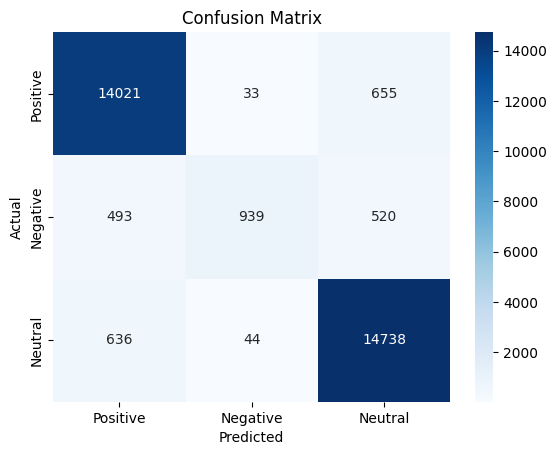

In [29]:
sns.heatmap(conf_vader, annot=True, fmt='d', cmap='Blues', xticklabels=labels_vader, yticklabels=labels_vader)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()